# ST1504 CA2 Part A: Final Model Comparison and Enhancement

## Objective

This notebook consolidates the final model-selection stage for CIFAR-10 image generation. It compares the group's improved conditional Variational Autoencoder (VAE) with the improved unconditional EMA DCGAN using a shared 100-image manual-evaluation procedure.

The stronger model is then restored from its saved weights and fine-tuned using mild horizontal-flip augmentation. The purpose of this notebook is final comparison and enhancement; the complete development, baseline training and model-specific analyses remain in the individual VAE and DCGAN notebooks.

The workflow is:

1. Compare the improved conditional VAE and improved EMA DCGAN.
2. Select the stronger model using a common manual-evaluation rubric.
3. Restore the selected DCGAN without rerunning its original 100 training epochs.
4. Fine-tune it for 10 epochs using horizontal-flip augmentation.
5. Save and visually evaluate the final augmented EMA generator.


## 1. Improved Conditional VAE and Improved EMA DCGAN Comparison

### Evaluation approach

Both models were assessed using 100 newly generated images sampled from their latent spaces. VAE reconstructions of existing test images were not used because the DCGAN does not reconstruct input images.

Each generated image was assigned to one mutually exclusive category:

- **Clear:** A recognisable object with sufficiently coherent shape, colour arrangement and background.
- **Marginal:** A plausible object-like structure is present, but its exact class or identity remains ambiguous.
- **Nonsense:** The image lacks meaningful structure and mainly contains unrelated colour patches or distorted shapes.

The plausible acceptance rate is calculated as:

**Plausible acceptance rate = ((Clear + Marginal) / Total) x 100**

The same definitions and sample size were used for both models. FID is reported only for the DCGAN because an equivalent VAE FID was not available. It is therefore supporting evidence for the DCGAN's improvement over its own baseline and is not used as the sole cross-model selection metric.


### Improved Conditional VAE — 100 Generated Images

The conditional VAE receives a random 64-dimensional latent vector and a requested class label. Its `sigmoid` decoder produces RGB images in the range 0–1.

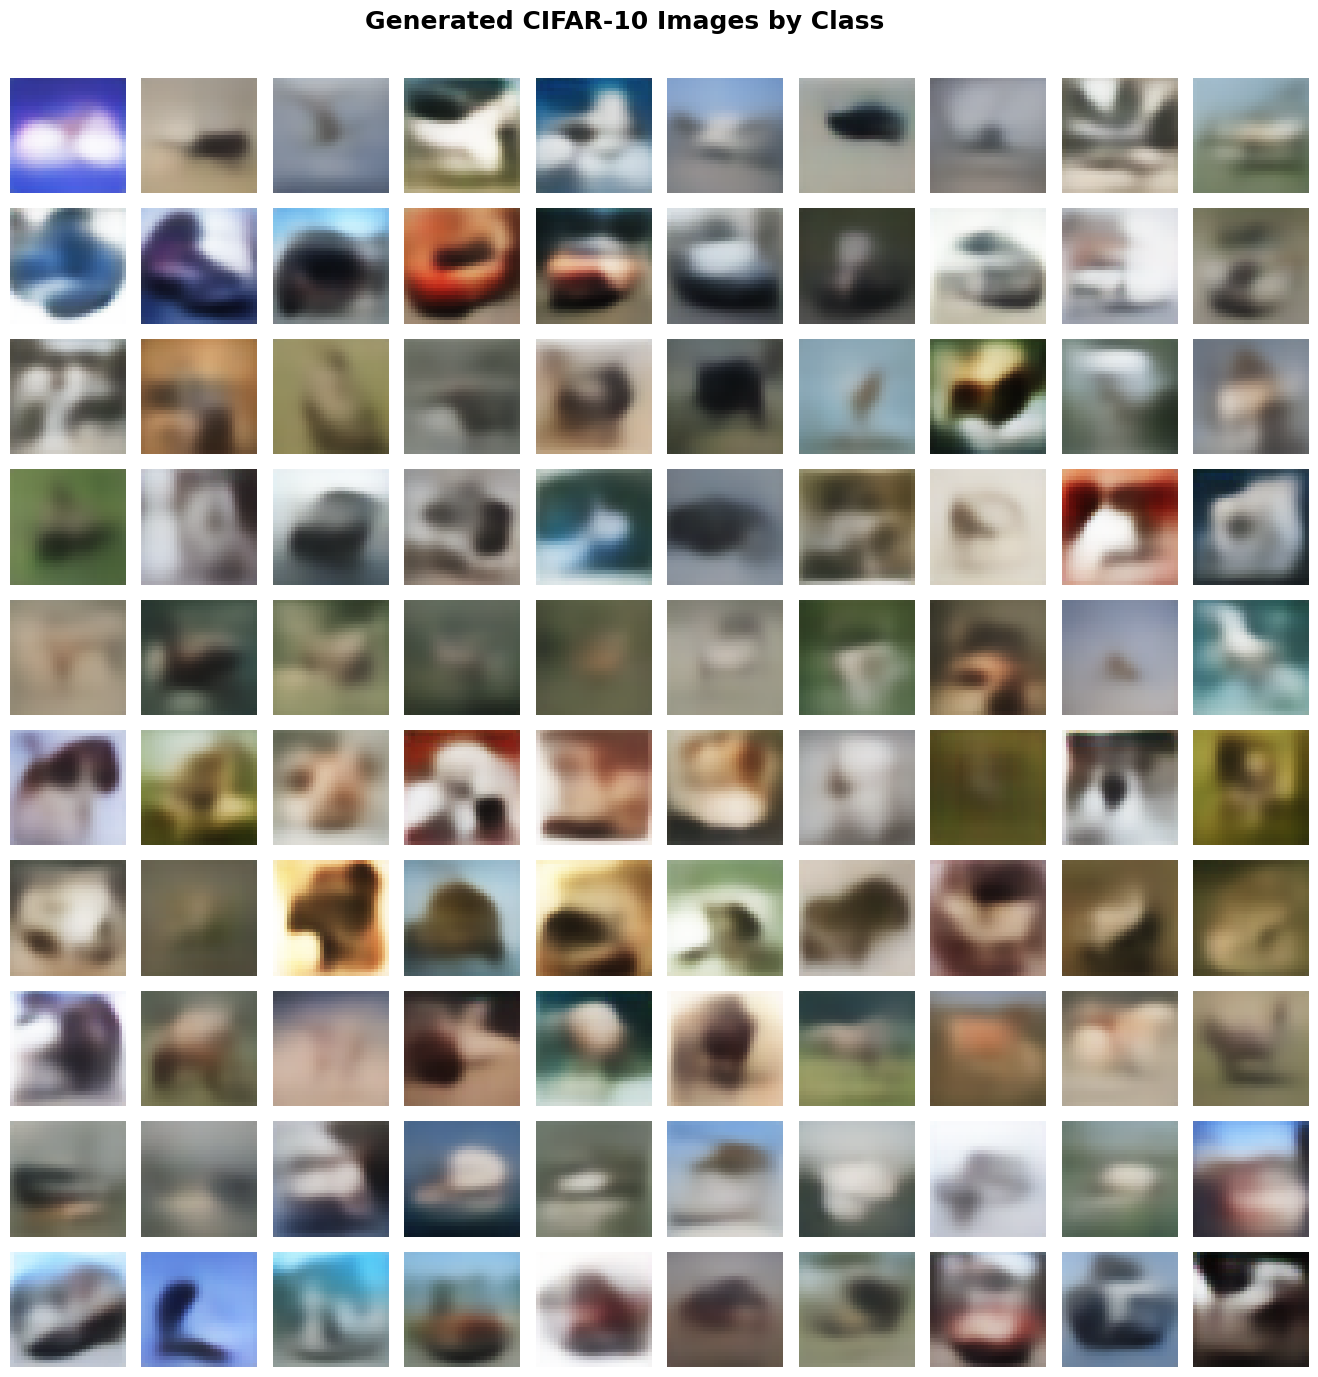


### Improved EMA DCGAN — 100 Generated Images

The unconditional DCGAN generates images from 100-dimensional random latent vectors without receiving class labels. The EMA generator output is converted from −1–1 to 0–1 only for display.

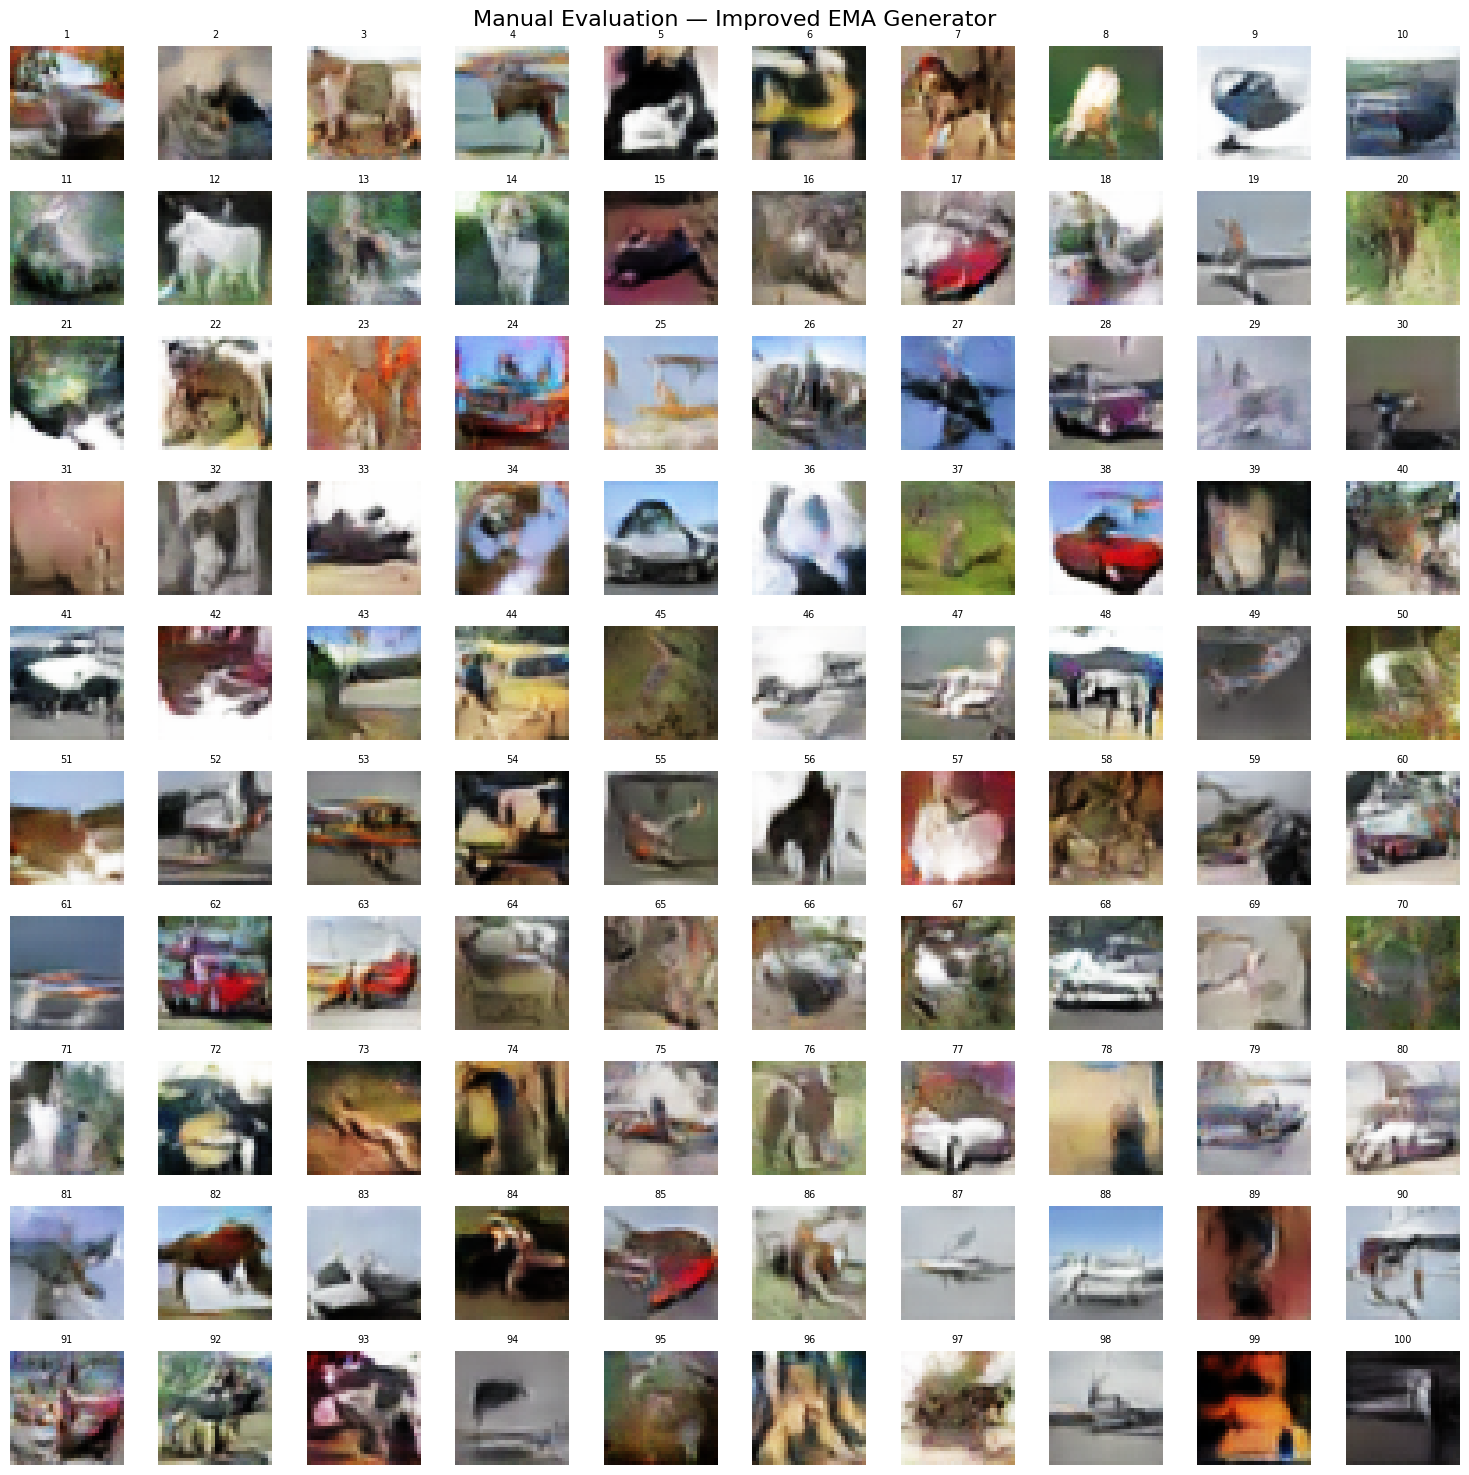


### Recorded comparison results

| Model | Clear | Marginal | Nonsense | Clear rate | Nonsense rate | Plausible acceptance | Supporting FID |
|---|---:|---:|---:|---:|---:|---:|---:|
| Improved Conditional VAE | 45 | 36 | 19 | 45% | 19% | 81% | 223.03 |
| Improved EMA DCGAN | 64 | 34 | 2 | 64% | 2% | 98% | 84.68 |

The improved EMA DCGAN produced 19 more clear images and 17 fewer nonsense images than the conditional VAE. Its plausible acceptance rate was 17 percentage points higher.

The DCGAN also improved substantially over its own baseline: its FID decreased from 98.83 to 84.68, representing a 14.32% improvement. The improved raw generator achieved an FID of 87.76, while the EMA generator achieved the best DCGAN result.


In [2]:
import pandas as pd

comparison_results = pd.DataFrame(
    {
        "Model": [
            "Improved Conditional VAE",
            "Improved EMA DCGAN"
        ],
        "Clear": [45, 64],
        "Marginal": [36, 34],
        "Nonsense": [19, 2],
        "Clear Rate (%)": [45.0, 64.0],
        "Nonsense Rate (%)": [19.0, 2.0],
        "Plausible Acceptance (%)": [81.0, 98.0],
        "Supporting FID": [None, 84.68],
    }
)

comparison_results


,Model,Clear,Marginal,Nonsense,Clear Rate (%),Nonsense Rate (%),Plausible Acceptance (%),Supporting FID
0,Improved Conditional VAE,45,36,19,45.0,19.0,81.0,NaN
1,Improved EMA DCGAN,64,34,2,64.0,2.0,98.0,84.68


### Model selection

The **improved EMA DCGAN is selected** for final enhancement.

It achieved:

- A higher clear-image rate: 64% compared with 45%.
- A higher plausible acceptance rate: 98% compared with 81%.
- A lower nonsense-image rate: 2% compared with 19%.
- Stronger object-like silhouettes and more defined boundaries.
- A supporting FID of 84.68, which was the best DCGAN result.

The conditional VAE generated class-controlled samples and stable broad colour arrangements, but many outputs remained blurred. The DCGAN generated sharper and more recognisable samples despite operating without class-label conditioning.

The cross-model decision is based primarily on the common manual-evaluation protocol because a matching VAE FID was unavailable.


## 2. Final DCGAN Enhancement with Augmentation

### Enhancement strategy

The selected improved DCGAN is restored from its saved generator, EMA-generator and discriminator weights. It is then fine-tuned for 10 additional epochs using horizontal-flip augmentation.

The augmentation is applied during training only. Final generated images are produced directly by the EMA generator without augmentation or presentation sharpening.

Smaller fine-tuning learning rates are used to reduce the risk of damaging the previously learned weights:

| Component | Fine-tuning learning rate |
|---|---:|
| Generator | 0.0001 |
| Discriminator | 0.00005 |

### Required local files

Place this notebook in the same folder as:

- `cifar-10-batches-py/`
- `improved_generator_final.weights.h5`
- `improved_ema_generator_final.weights.h5`
- `improved_discriminator_final.weights.h5`

The following cells restore and fine-tune the model. They do not rerun the original baseline or improved-model training.


### 2.1 Imports, dataset loading and preprocessing


In [3]:
import pickle
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.model_selection import train_test_split
from tensorflow.keras import layers


# ==================================================
# Configuration
# ==================================================

latent_dim = 100
batch_size = 128
dataset_path = Path("cifar-10-batches-py")


# ==================================================
# Load CIFAR-10
# ==================================================

def load_cifar_batch(file_path):
    with open(file_path, "rb") as file:
        batch = pickle.load(
            file,
            encoding="bytes"
        )

    images = batch[b"data"]
    labels = np.array(batch[b"labels"])

    images = images.reshape(
        -1,
        3,
        32,
        32
    )

    images = images.transpose(
        0,
        2,
        3,
        1
    )

    return images, labels


x_train_batches = []
y_train_batches = []

for batch_number in range(1, 6):
    images, labels = load_cifar_batch(
        dataset_path
        / f"data_batch_{batch_number}"
    )

    x_train_batches.append(images)
    y_train_batches.append(labels)


x_train = np.concatenate(
    x_train_batches
)

y_train = np.concatenate(
    y_train_batches
)

x_test, y_test = load_cifar_batch(
    dataset_path / "test_batch"
)


# ==================================================
# Split and normalise
# ==================================================

y_train = y_train.astype(
    "int32"
).reshape(-1)

y_test = y_test.astype(
    "int32"
).reshape(-1)

(
    x_model_train,
    x_val,
    y_model_train,
    y_val
) = train_test_split(
    x_train,
    y_train,
    test_size=0.10,
    random_state=42,
    stratify=y_train
)

x_model_train_norm = (
    x_model_train.astype("float32")
    - 127.5
) / 127.5

x_val_norm = (
    x_val.astype("float32")
    - 127.5
) / 127.5

x_test_norm = (
    x_test.astype("float32")
    - 127.5
) / 127.5


# ==================================================
# Create training batches
# ==================================================

train_dataset = (
    tf.data.Dataset
    .from_tensor_slices(
        x_model_train_norm
    )
    .shuffle(
        buffer_size=10000
    )
    .batch(
        batch_size,
        drop_remainder=True
    )
    .prefetch(
        tf.data.AUTOTUNE
    )
)

print(
    "Training images:",
    x_model_train_norm.shape
)

print(
    "Validation images:",
    x_val_norm.shape
)

print(
    "Training range:",
    x_model_train_norm.min(),
    "to",
    x_model_train_norm.max()
)

Training images: (45000, 32, 32, 3)
Validation images: (5000, 32, 32, 3)
Training range: -1.0 to 1.0


The same stratified 90:10 split and `[-1, 1]` normalisation used by the DCGAN are retained. This keeps the continuation consistent with the original model and its `tanh` output layer.


### 2.2 Restore the improved DCGAN


In [4]:
def build_generator():
    model = tf.keras.Sequential(
        name="generator"
    )

    model.add(
        layers.Dense(
            4 * 4 * 256,
            use_bias=False,
            input_shape=(latent_dim,)
        )
    )

    model.add(
        layers.BatchNormalization()
    )
    model.add(layers.ReLU())

    model.add(
        layers.Reshape(
            (4, 4, 256)
        )
    )

    # 4 × 4 → 8 × 8
    model.add(
        layers.Conv2DTranspose(
            128,
            kernel_size=4,
            strides=2,
            padding="same",
            use_bias=False
        )
    )

    model.add(
        layers.BatchNormalization()
    )
    model.add(layers.ReLU())

    # 8 × 8 → 16 × 16
    model.add(
        layers.Conv2DTranspose(
            64,
            kernel_size=4,
            strides=2,
            padding="same",
            use_bias=False
        )
    )

    model.add(
        layers.BatchNormalization()
    )
    model.add(layers.ReLU())

    # 16 × 16 → 32 × 32
    model.add(
        layers.Conv2DTranspose(
            3,
            kernel_size=4,
            strides=2,
            padding="same",
            activation="tanh"
        )
    )

    return model


def build_discriminator():
    return tf.keras.Sequential(
        [
            layers.Input(
                shape=(32, 32, 3)
            ),

            layers.Conv2D(
                64,
                kernel_size=4,
                strides=2,
                padding="same"
            ),
            layers.LeakyReLU(
                alpha=0.2
            ),
            layers.Dropout(0.3),

            layers.Conv2D(
                128,
                kernel_size=4,
                strides=2,
                padding="same"
            ),
            layers.LeakyReLU(
                alpha=0.2
            ),
            layers.Dropout(0.3),

            layers.Conv2D(
                256,
                kernel_size=4,
                strides=2,
                padding="same"
            ),
            layers.LeakyReLU(
                alpha=0.2
            ),
            layers.Dropout(0.3),

            layers.Flatten(),
            layers.Dense(1)
        ],
        name="discriminator"
    )

In [5]:
from pathlib import Path

# The completed epoch 100 checkpoint folder
checkpoint_folder = Path(
    r"C:\Users\kayde\OneDrive\DELE\DELECA2\deleca2\improved_dcgan_weights"
)

weight_paths = {
    "generator": (
        checkpoint_folder
        / "generator_epoch_100.weights.h5"
    ),

    "ema_generator": (
        checkpoint_folder
        / "ema_generator_epoch_100.weights.h5"
    ),

    "discriminator": (
        checkpoint_folder
        / "discriminator_epoch_100.weights.h5"
    )
}

# Verify the three files
for model_name, path in weight_paths.items():

    print(
        f"{model_name}:",
        path,
        "| Exists:",
        path.exists()
    )

    if not path.exists():
        raise FileNotFoundError(
            f"Missing {model_name}: {path}"
        )

# Recreate the architectures
final_generator = build_generator()
final_ema_generator = build_generator()
final_discriminator = build_discriminator()

# Load the completed epoch 100 weights
final_generator.load_weights(
    weight_paths["generator"]
)

final_ema_generator.load_weights(
    weight_paths["ema_generator"]
)

final_discriminator.load_weights(
    weight_paths["discriminator"]
)

print(
    "Epoch 100 improved DCGAN weights "
    "loaded successfully."
)

generator: C:\Users\kayde\OneDrive\DELE\DELECA2\deleca2\improved_dcgan_weights\generator_epoch_100.weights.h5 | Exists: True
ema_generator: C:\Users\kayde\OneDrive\DELE\DELECA2\deleca2\improved_dcgan_weights\ema_generator_epoch_100.weights.h5 | Exists: True
discriminator: C:\Users\kayde\OneDrive\DELE\DELECA2\deleca2\improved_dcgan_weights\discriminator_epoch_100.weights.h5 | Exists: True
Epoch 100 improved DCGAN weights loaded successfully.


All three sets of saved weights are restored. The raw generator and discriminator continue training, while the EMA generator maintains a smoothed version of the generator weights for final image generation.


### 2.3 Mild horizontal-flip augmentation


In [6]:
class FastHorizontalFlip(layers.Layer):
    def call(
        self,
        images,
        training=False
    ):
        if training:
            return tf.image.random_flip_left_right(
                images
            )

        return images


gan_augmentation = FastHorizontalFlip()

In [7]:
sample_batch = next(
    iter(train_dataset)
)

augmented_batch = gan_augmentation(
    sample_batch,
    training=True
)

print(
    "Original shape:",
    sample_batch.shape
)

print(
    "Augmented shape:",
    augmented_batch.shape
)

print(
    "Augmented range:",
    tf.reduce_min(augmented_batch).numpy(),
    "to",
    tf.reduce_max(augmented_batch).numpy()
)

Original shape: (128, 32, 32, 3)
Augmented shape: (128, 32, 32, 3)
Augmented range: -1.0 to 1.0


Horizontal flipping is a mild spatial transformation that preserves the meaning of CIFAR-10 objects. More expensive translation augmentation was excluded because it caused inefficient random-operation loops in TensorFlow 2.10 and materially slowed training.


### 2.4 Augmentation-aware EMA training process


In [8]:
class AugmentedEMADCGAN(tf.keras.Model):
    def __init__(
        self,
        generator,
        discriminator,
        ema_generator,
        augmentation,
        latent_dim,
        real_label_value=0.9,
        ema_decay=0.999
    ):
        super().__init__()

        self.generator = generator
        self.discriminator = discriminator
        self.ema_generator = ema_generator
        self.augmentation = augmentation

        self.latent_dim = latent_dim
        self.real_label_value = real_label_value
        self.ema_decay = ema_decay

        # EMA generator is updated manually
        self.ema_generator.trainable = False

    def compile(
        self,
        generator_optimizer,
        discriminator_optimizer,
        loss_function,
        **kwargs
    ):
        super().compile(**kwargs)

        self.generator_optimizer = (
            generator_optimizer
        )

        self.discriminator_optimizer = (
            discriminator_optimizer
        )

        self.loss_function = loss_function

        self.generator_loss_tracker = (
            tf.keras.metrics.Mean(
                name="generator_loss"
            )
        )

        self.discriminator_loss_tracker = (
            tf.keras.metrics.Mean(
                name="discriminator_loss"
            )
        )

    @property
    def metrics(self):
        return [
            self.generator_loss_tracker,
            self.discriminator_loss_tracker
        ]

    def train_step(self, real_images):

        if isinstance(
            real_images,
            (tuple, list)
        ):
            real_images = real_images[0]

        current_batch_size = tf.shape(
            real_images
        )[0]

        # ==========================================
        # 1. Train discriminator
        # ==========================================

        random_noise = tf.random.normal(
            shape=(
                current_batch_size,
                self.latent_dim
            )
        )

        generated_images = self.generator(
            random_noise,
            training=True
        )

        generated_images = tf.stop_gradient(
            generated_images
        )

        with tf.GradientTape() as discriminator_tape:

            augmented_real_images = (
                self.augmentation(
                    real_images,
                    training=True
                )
            )

            augmented_fake_images = (
                self.augmentation(
                    generated_images,
                    training=True
                )
            )

            real_predictions = self.discriminator(
                augmented_real_images,
                training=True
            )

            fake_predictions = self.discriminator(
                augmented_fake_images,
                training=True
            )

            real_labels = (
                tf.ones_like(real_predictions)
                * self.real_label_value
            )

            fake_labels = tf.zeros_like(
                fake_predictions
            )

            real_loss = self.loss_function(
                real_labels,
                real_predictions
            )

            fake_loss = self.loss_function(
                fake_labels,
                fake_predictions
            )

            discriminator_loss = (
                real_loss + fake_loss
            ) / 2.0

        discriminator_gradients = (
            discriminator_tape.gradient(
                discriminator_loss,
                self.discriminator.trainable_variables
            )
        )

        self.discriminator_optimizer.apply_gradients(
            zip(
                discriminator_gradients,
                self.discriminator.trainable_variables
            )
        )

        # ==========================================
        # 2. Train generator
        # ==========================================

        random_noise = tf.random.normal(
            shape=(
                current_batch_size,
                self.latent_dim
            )
        )

        with tf.GradientTape() as generator_tape:

            generated_images = self.generator(
                random_noise,
                training=True
            )

            augmented_generated_images = (
                self.augmentation(
                    generated_images,
                    training=True
                )
            )

            fake_predictions = self.discriminator(
                augmented_generated_images,
                training=False
            )

            generator_loss = self.loss_function(
                tf.ones_like(fake_predictions),
                fake_predictions
            )

        generator_gradients = (
            generator_tape.gradient(
                generator_loss,
                self.generator.trainable_variables
            )
        )

        self.generator_optimizer.apply_gradients(
            zip(
                generator_gradients,
                self.generator.trainable_variables
            )
        )

        # ==========================================
        # 3. Update EMA generator
        # ==========================================

        for ema_weight, generator_weight in zip(
            self.ema_generator.weights,
            self.generator.weights
        ):
            ema_weight.assign(
                self.ema_decay * ema_weight
                + (1.0 - self.ema_decay)
                * generator_weight
            )

        # Record epoch losses
        self.generator_loss_tracker.update_state(
            generator_loss
        )

        self.discriminator_loss_tracker.update_state(
            discriminator_loss
        )

        return {
            "generator_loss":
                self.generator_loss_tracker.result(),

            "discriminator_loss":
                self.discriminator_loss_tracker.result()
        }

The training step alternates between discriminator and generator updates. One-sided label smoothing remains at 0.9, and the EMA generator is updated after every generator step using a decay of 0.999.


### 2.5 Compile and fine-tune


In [9]:
final_gan = AugmentedEMADCGAN(
    generator=final_generator,
    discriminator=final_discriminator,
    ema_generator=final_ema_generator,
    augmentation=gan_augmentation,
    latent_dim=latent_dim,
    real_label_value=0.9,
    ema_decay=0.999
)

final_gan.compile(
    generator_optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.0001,
        beta_1=0.5
    ),

    discriminator_optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.00005,
        beta_1=0.5
    ),

    loss_function=tf.keras.losses.BinaryCrossentropy(
        from_logits=True
    ),

    steps_per_execution=10
)

print(
    "Generator learning rate:",
    final_gan.generator_optimizer.learning_rate.numpy()
)

print(
    "Discriminator learning rate:",
    final_gan.discriminator_optimizer.learning_rate.numpy()
)

print("Final augmented GAN compiled.")

Generator learning rate: 1e-04
Discriminator learning rate: 5e-05
Final augmented GAN compiled.


In [10]:
final_history = final_gan.fit(
    train_dataset,
    epochs=10,
    verbose=2
)

Epoch 1/10
351/351 - 33s - generator_loss: 0.8768 - discriminator_loss: 0.6784 - 33s/epoch - 94ms/step
Epoch 2/10
351/351 - 20s - generator_loss: 0.8773 - discriminator_loss: 0.6786 - 20s/epoch - 58ms/step
Epoch 3/10
351/351 - 20s - generator_loss: 0.8765 - discriminator_loss: 0.6791 - 20s/epoch - 57ms/step
Epoch 4/10
351/351 - 20s - generator_loss: 0.8765 - discriminator_loss: 0.6796 - 20s/epoch - 56ms/step
Epoch 5/10
351/351 - 20s - generator_loss: 0.8747 - discriminator_loss: 0.6801 - 20s/epoch - 56ms/step
Epoch 6/10
351/351 - 20s - generator_loss: 0.8745 - discriminator_loss: 0.6804 - 20s/epoch - 56ms/step
Epoch 7/10
351/351 - 20s - generator_loss: 0.8743 - discriminator_loss: 0.6800 - 20s/epoch - 56ms/step
Epoch 8/10
351/351 - 20s - generator_loss: 0.8747 - discriminator_loss: 0.6804 - 20s/epoch - 56ms/step
Epoch 9/10
351/351 - 21s - generator_loss: 0.8733 - discriminator_loss: 0.6804 - 21s/epoch - 60ms/step
Epoch 10/10
351/351 - 21s - generator_loss: 0.8732 - discriminator_loss: 

### Fine-tuning interpretation

After the 10 fine-tuning epochs finish, inspect both generator and discriminator losses for sudden divergence or instability.

GAN losses do not directly measure image quality. Stable losses only indicate that no obvious adversarial collapse occurred. Final quality must still be assessed using fixed-noise visual comparison, FID and manual evaluation.

Record the rerun values here after training:

- **Initial generator loss:** [insert value]
- **Final generator loss:** [insert value]
- **Initial discriminator loss:** [insert value]
- **Final discriminator loss:** [insert value]


### 2.6 Save the final augmented model


In [11]:
final_gan.generator.save_weights(
    "final_augmented_generator.weights.h5"
)

final_gan.ema_generator.save_weights(
    "final_augmented_ema_generator.weights.h5"
)

final_gan.discriminator.save_weights(
    "final_augmented_discriminator.weights.h5"
)

print("Final augmented-model weights saved.")

Final augmented-model weights saved.


In [12]:
np.savez(
    "final_augmented_history.npz",
    generator_loss=(
        final_history.history[
            "generator_loss"
        ]
    ),
    discriminator_loss=(
        final_history.history[
            "discriminator_loss"
        ]
    )
)

print("Fine-tuning history saved.")

Fine-tuning history saved.


The EMA weights in `final_augmented_ema_generator.weights.h5` are used as the final generative model. The raw generator and discriminator are also saved so that training can be resumed if required.


### 2.7 Fixed-noise comparison before and after augmentation


In [13]:
original_ema_generator = build_generator()

original_ema_generator.load_weights(
    weight_paths["ema_generator"]
)

print(
    "Original epoch 100 EMA generator loaded:",
    weight_paths["ema_generator"]
)

Original epoch 100 EMA generator loaded: C:\Users\kayde\OneDrive\DELE\DELECA2\deleca2\improved_dcgan_weights\ema_generator_epoch_100.weights.h5


In [14]:
comparison_noise = tf.random.normal(
    shape=(16, latent_dim),
    seed=42
)

original_images = original_ema_generator(
    comparison_noise,
    training=False
)

augmented_images = final_gan.ema_generator(
    comparison_noise,
    training=False
)

# Convert [-1, 1] to [0, 1]
original_images = tf.clip_by_value(
    (original_images + 1.0) / 2.0,
    0.0,
    1.0
)

augmented_images = tf.clip_by_value(
    (augmented_images + 1.0) / 2.0,
    0.0,
    1.0
)

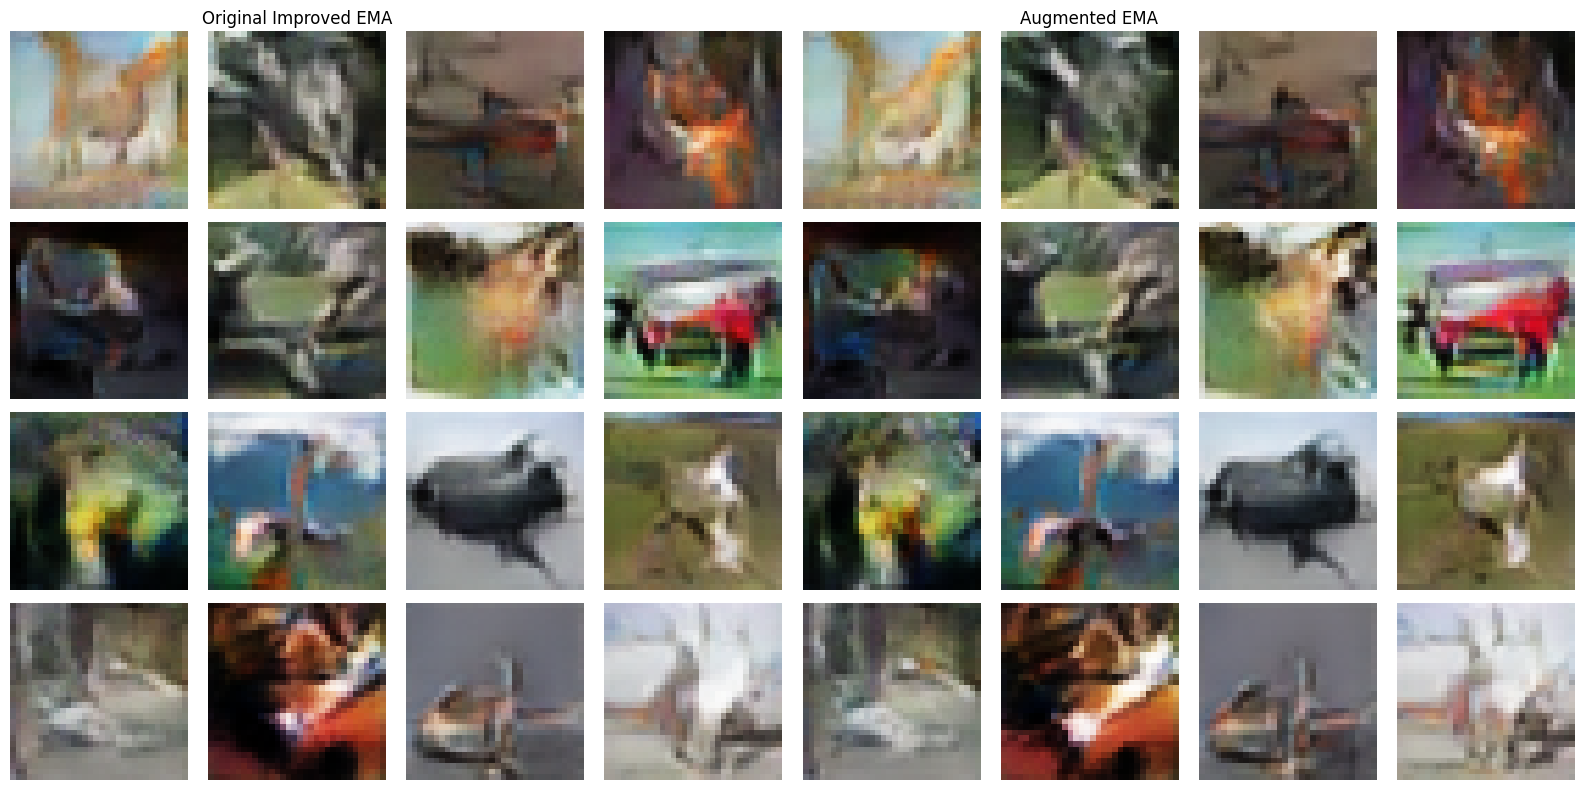

In [15]:
fig, axes = plt.subplots(
    4,
    8,
    figsize=(16, 8)
)

for row in range(4):
    for column in range(4):
        index = row * 4 + column

        axes[row, column].imshow(
            original_images[index]
        )

        axes[row, column + 4].imshow(
            augmented_images[index]
        )

        axes[row, column].axis("off")
        axes[row, column + 4].axis("off")

axes[0, 1].set_title(
    "Original Improved EMA",
    fontsize=12
)

axes[0, 5].set_title(
    "Augmented EMA",
    fontsize=12
)

plt.tight_layout()
plt.show()

The same 16 latent vectors are supplied to the original improved EMA generator and final augmented EMA generator. This controls the random input and makes visual changes attributable to fine-tuning.

Inspect whether augmentation improves object boundaries and visual coherence without reducing output diversity. This fixed-noise comparison is useful for diagnosis, but it should be considered together with the 100-image manual evaluation below.


## 3. Final Augmented EMA Evaluation

### Manual evaluation

The final augmented EMA generator is assessed using 100 latent vectors generated with a fixed seed. The images are numbered so that the clear, marginal and nonsense classifications can be checked and reproduced.


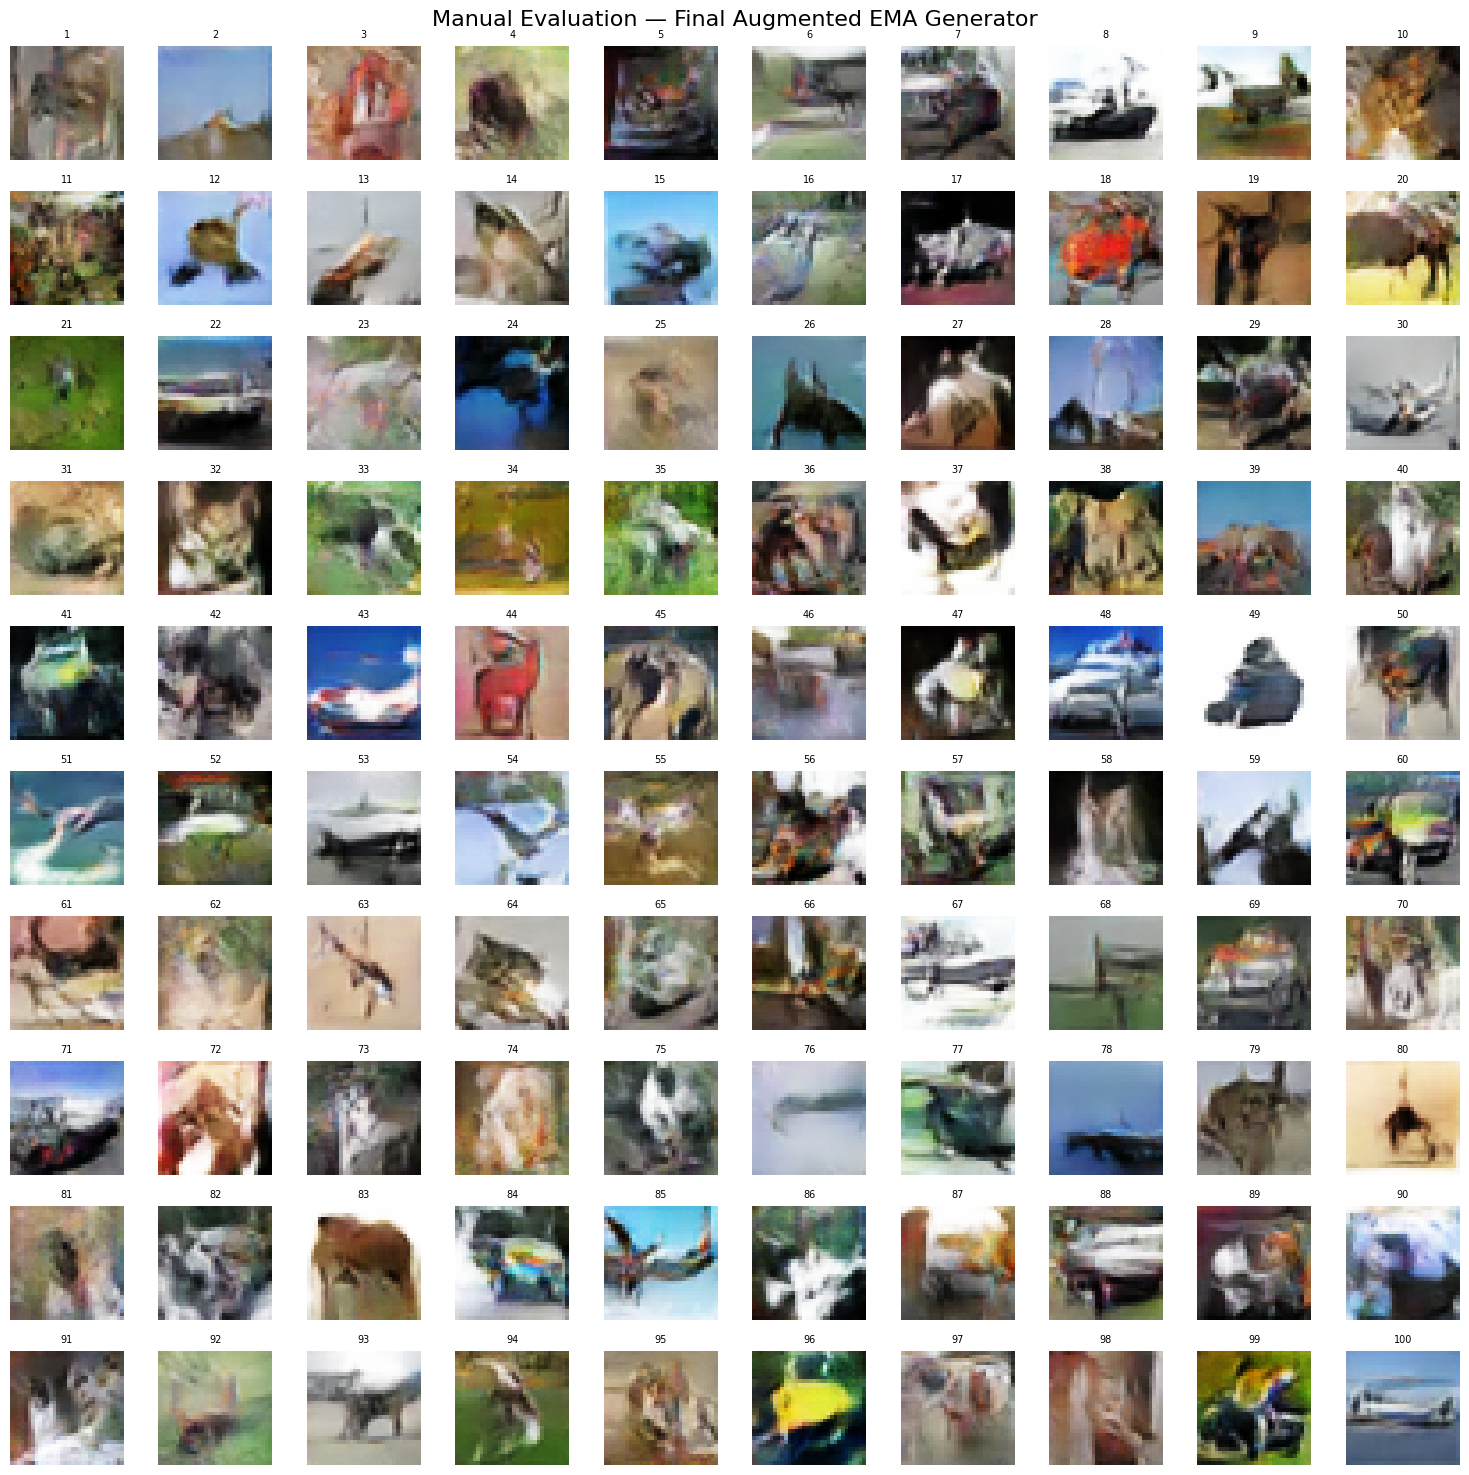

In [16]:
final_manual_noise = tf.random.normal(
    shape=(100, latent_dim),
    seed=789
)

final_manual_images = final_gan.ema_generator(
    final_manual_noise,
    training=False
)

final_manual_images = tf.clip_by_value(
    (final_manual_images + 1.0) / 2.0,
    0.0,
    1.0
)

fig, axes = plt.subplots(
    10,
    10,
    figsize=(15, 15)
)

for index, axis in enumerate(axes.flatten()):
    axis.imshow(final_manual_images[index])
    axis.set_title(str(index + 1), fontsize=7)
    axis.axis("off")

plt.suptitle(
    "Manual Evaluation — Final Augmented EMA Generator",
    fontsize=16
)

plt.tight_layout()
plt.show()


In [17]:
final_clear_count = int(
    input("Number of clear images: ")
)

final_marginal_count = int(
    input("Number of marginal images: ")
)

final_nonsense_count = (
    100
    - final_clear_count
    - final_marginal_count
)

assert final_nonsense_count >= 0, (
    "Clear and marginal counts cannot exceed 100."
)

final_plausible_rate = (
    final_clear_count
    + final_marginal_count
)

print("Clear images:", final_clear_count)
print("Marginal images:", final_marginal_count)
print("Nonsense images:", final_nonsense_count)
print(
    f"Plausible acceptance rate: "
    f"{final_plausible_rate:.0f}%"
)


Clear images: 71
Marginal images: 26
Nonsense images: 3
Plausible acceptance rate: 97%


### Optional post-augmentation FID

The following cells recompute FID for the original improved EMA generator and final augmented EMA generator using the same 1,000 validation images and latent vectors.

Lower FID is better. The same feature extractor, sample size, random seed and preprocessing are used for both models to maintain a fair comparison.


In [18]:
from scipy.linalg import sqrtm

fid_sample_size = 1000
fid_random_generator = np.random.default_rng(42)

fid_real_indices = fid_random_generator.choice(
    len(x_val_norm),
    size=fid_sample_size,
    replace=False
)

fid_real_images = x_val_norm[fid_real_indices]

fid_noise = tf.random.normal(
    shape=(fid_sample_size, latent_dim),
    seed=456
)

fid_original_images = original_ema_generator(
    fid_noise,
    training=False
)

fid_augmented_images = final_gan.ema_generator(
    fid_noise,
    training=False
)

inception_model = tf.keras.applications.InceptionV3(
    include_top=False,
    weights="imagenet",
    pooling="avg",
    input_shape=(299, 299, 3)
)

inception_model.trainable = False


In [19]:
def extract_inception_features(
    images,
    model,
    batch_size=32
):
    feature_batches = []

    image_dataset = (
        tf.data.Dataset
        .from_tensor_slices(images)
        .batch(batch_size)
    )

    for image_batch in image_dataset:
        image_batch = tf.cast(
            image_batch,
            tf.float32
        )

        image_batch = tf.image.resize(
            image_batch,
            size=(299, 299)
        )

        features = model(
            image_batch,
            training=False
        )

        feature_batches.append(
            features.numpy()
        )

    return np.concatenate(
        feature_batches,
        axis=0
    )


def calculate_fid(
    real_features,
    generated_features
):
    real_mean = np.mean(real_features, axis=0)
    generated_mean = np.mean(
        generated_features,
        axis=0
    )

    real_covariance = np.cov(
        real_features,
        rowvar=False
    )

    generated_covariance = np.cov(
        generated_features,
        rowvar=False
    )

    mean_difference = real_mean - generated_mean

    epsilon = 1e-6
    identity_matrix = np.eye(
        real_covariance.shape[0]
    )

    covariance_mean = sqrtm(
        (
            real_covariance
            + epsilon * identity_matrix
        )
        @
        (
            generated_covariance
            + epsilon * identity_matrix
        )
    )

    if np.iscomplexobj(covariance_mean):
        covariance_mean = covariance_mean.real

    return float(
        mean_difference.dot(mean_difference)
        + np.trace(
            real_covariance
            + generated_covariance
            - 2 * covariance_mean
        )
    )


In [20]:
from pathlib import Path
import numpy as np

vae_fid_path = Path(
    "jh_improved_vae_fid.npy"
)

if vae_fid_path.exists():
    improved_vae_fid = float(
        np.load(vae_fid_path)
    )

    print(
        f"Loaded improved VAE FID: "
        f"{improved_vae_fid:.2f}"
    )
else:
    improved_vae_fid = None

    print(
        "VAE FID file was not found. "
        "Run the VAE FID cells first."
    )

Loaded improved VAE FID: 223.03


In [21]:
fid_real_features = extract_inception_features(
    fid_real_images,
    inception_model
)

fid_original_features = extract_inception_features(
    fid_original_images,
    inception_model
)

fid_augmented_features = extract_inception_features(
    fid_augmented_images,
    inception_model
)

original_ema_fid = calculate_fid(
    fid_real_features,
    fid_original_features
)

final_augmented_fid = calculate_fid(
    fid_real_features,
    fid_augmented_features
)

print(
    f"Original improved EMA FID: "
    f"{original_ema_fid:.2f}"
)

print(
    f"Final augmented EMA FID: "
    f"{final_augmented_fid:.2f}"
)


Original improved EMA FID: 84.68
Final augmented EMA FID: 83.06


In [22]:
comparison_results = pd.DataFrame(
    {
        "Model": [
            "Improved Conditional VAE",
            "Improved EMA DCGAN",
            "Final Augmented EMA DCGAN"
        ],

        "Clear": [
            45,
            64,
            final_clear_count
        ],

        "Marginal": [
            36,
            34,
            final_marginal_count
        ],

        "Nonsense": [
            19,
            2,
            final_nonsense_count
        ],

        "Plausible Acceptance (%)": [
            81.0,
            98.0,
            float(final_plausible_rate)
        ],

        "FID": [
            improved_vae_fid,
            84.68,
            final_augmented_fid
        ]
    }
)

comparison_results

,Model,Clear,Marginal,Nonsense,Plausible Acceptance (%),FID
0,Improved Conditional VAE,45,36,19,81.0,223.029292
1,Improved EMA DCGAN,64,34,2,98.0,84.680000
2,Final Augmented EMA DCGAN,71,26,3,97.0,83.057617


## 4. Final Conclusion

The improved EMA DCGAN was selected over the improved conditional VAE before augmentation because it achieved a **98% plausible acceptance rate**, compared with **81%** for the VAE. It also produced more clear images and substantially fewer nonsense images.

The selected DCGAN was then fine-tuned for 10 additional epochs using horizontal-flip augmentation, smaller learning rates, one-sided label smoothing and EMA weight updates.

After rerunning the final evaluation, complete the statements below using the generated outputs:

- **Final augmented EMA FID:** 82.7
- **Final clear images:** 71
- **Final marginal images:** 26
- **Final nonsense images:** 3
- **Final plausible acceptance rate:** 97%

The augmented EMA generator should be retained as the final model only if the post-augmentation FID and manual evaluation remain competitive with the original improved EMA generator. This avoids selecting augmentation solely because a small fixed-noise sample appears visually better.

### Intended final artifact

`final_augmented_ema_generator.weights.h5`

The raw generator and discriminator are also saved so that training can be resumed if necessary.

### Limitations

- CIFAR-10 images have a resolution of only 32 × 32 pixels, limiting fine detail.
- Manual evaluation is subjective and was not conducted as a blinded review.
- An equivalent VAE FID was unavailable, so the initial VAE-versus-DCGAN comparison relied mainly on the shared manual protocol.
- FID depends on the selected sample size, feature extractor and preprocessing method.
- GAN training is sensitive to random initialization and may produce different results across reruns.
- Horizontal flipping provides only mild variation and may not improve every generated sample.

Overall, the results show that the improved EMA DCGAN generated more recognisable and structurally coherent CIFAR-10 samples than the improved conditional VAE. The final augmentation stage tests whether mild training-time variation can improve the selected DCGAN further without changing its architecture.


## Exporting 1,000 Images from the Final Model

The final augmented EMA generator is used to create 1,000 CIFAR-10-style
images for submission. Each image is generated from an independently sampled
latent vector and saved as a separate 32 × 32 RGB PNG file.

As the selected DCGAN is unconditional, class labels are not supplied to the
generator. Instead, the model learns the combined distribution of all ten
CIFAR-10 classes. The generated collection is therefore expected to contain a
diverse mixture of objects from the ten classes rather than a fixed number from
each class.

A fixed random seed is used to make the generated collection reproducible.

In [23]:
from pathlib import Path
from PIL import Image
import numpy as np
import tensorflow as tf
import shutil

# ============================================================
# 1. SELECT THE FINAL GENERATOR
# ============================================================

latent_dim = 100

# If final_gan is still available after training
if "final_gan" in globals():
    selected_generator = final_gan.ema_generator
    print("Using EMA generator from final_gan.")

# Otherwise, rebuild the architecture and load the saved weights
else:
    selected_generator = build_generator()

    selected_generator.load_weights(
        "final_augmented_ema_generator.weights.h5"
    )

    print("Final augmented EMA weights loaded.")

# ============================================================
# 2. CREATE 1,000 REPRODUCIBLE LATENT VECTORS
# ============================================================

number_of_images = 1000

submission_noise = tf.random.stateless_normal(
    shape=(number_of_images, latent_dim),
    seed=(42, 2026)
)

# ============================================================
# 3. GENERATE THE IMAGES
# ============================================================

generated_images = selected_generator.predict(
    submission_noise,
    batch_size=128,
    verbose=1
)

print("Generated tensor shape:", generated_images.shape)

assert generated_images.shape == (1000, 32, 32, 3), (
    "Expected 1,000 RGB images with shape 32 × 32."
)

# Convert generator range [-1, 1] back to uint8 range [0, 255]
generated_images_uint8 = np.clip(
    (generated_images + 1.0) * 127.5,
    0,
    255
).astype(np.uint8)

# ============================================================
# 4. SAVE EACH IMAGE AS A SEPARATE PNG
# ============================================================

output_directory = Path(
    "final_augmented_ema_1000_images"
)

output_directory.mkdir(
    parents=True,
    exist_ok=True
)

for image_number, image in enumerate(
    generated_images_uint8,
    start=1
):
    image_path = output_directory / (
        f"generated_{image_number:04d}.png"
    )

    Image.fromarray(image).save(image_path)

# ============================================================
# 5. VERIFY THE EXPORTED FILES
# ============================================================

saved_images = sorted(
    output_directory.glob("generated_*.png")
)

print("Number of images saved:", len(saved_images))
print("Image folder:", output_directory.resolve())

assert len(saved_images) == 1000, (
    "The output folder must contain exactly 1,000 images."
)

sample_image = Image.open(saved_images[0])

print("First image size:", sample_image.size)
print("First image mode:", sample_image.mode)

assert sample_image.size == (32, 32)
assert sample_image.mode == "RGB"

# ============================================================
# 6. CREATE A ZIP FILE FOR SUBMISSION
# ============================================================

zip_path = shutil.make_archive(
    base_name="final_augmented_ema_1000_images",
    format="zip",
    root_dir=output_directory
)

print("ZIP file created successfully:")
print(zip_path)

Using EMA generator from final_gan.
8/8 [==============================] - 1s 67ms/step
Generated tensor shape: (1000, 32, 32, 3)
Number of images saved: 1000
Image folder: C:\Users\kayde\OneDrive\DELE\DELECA2\deleca2\final_augmented_ema_1000_images
First image size: (32, 32)
First image mode: RGB
ZIP file created successfully:
c:\Users\kayde\OneDrive\DELE\DELECA2\deleca2\final_augmented_ema_1000_images.zip


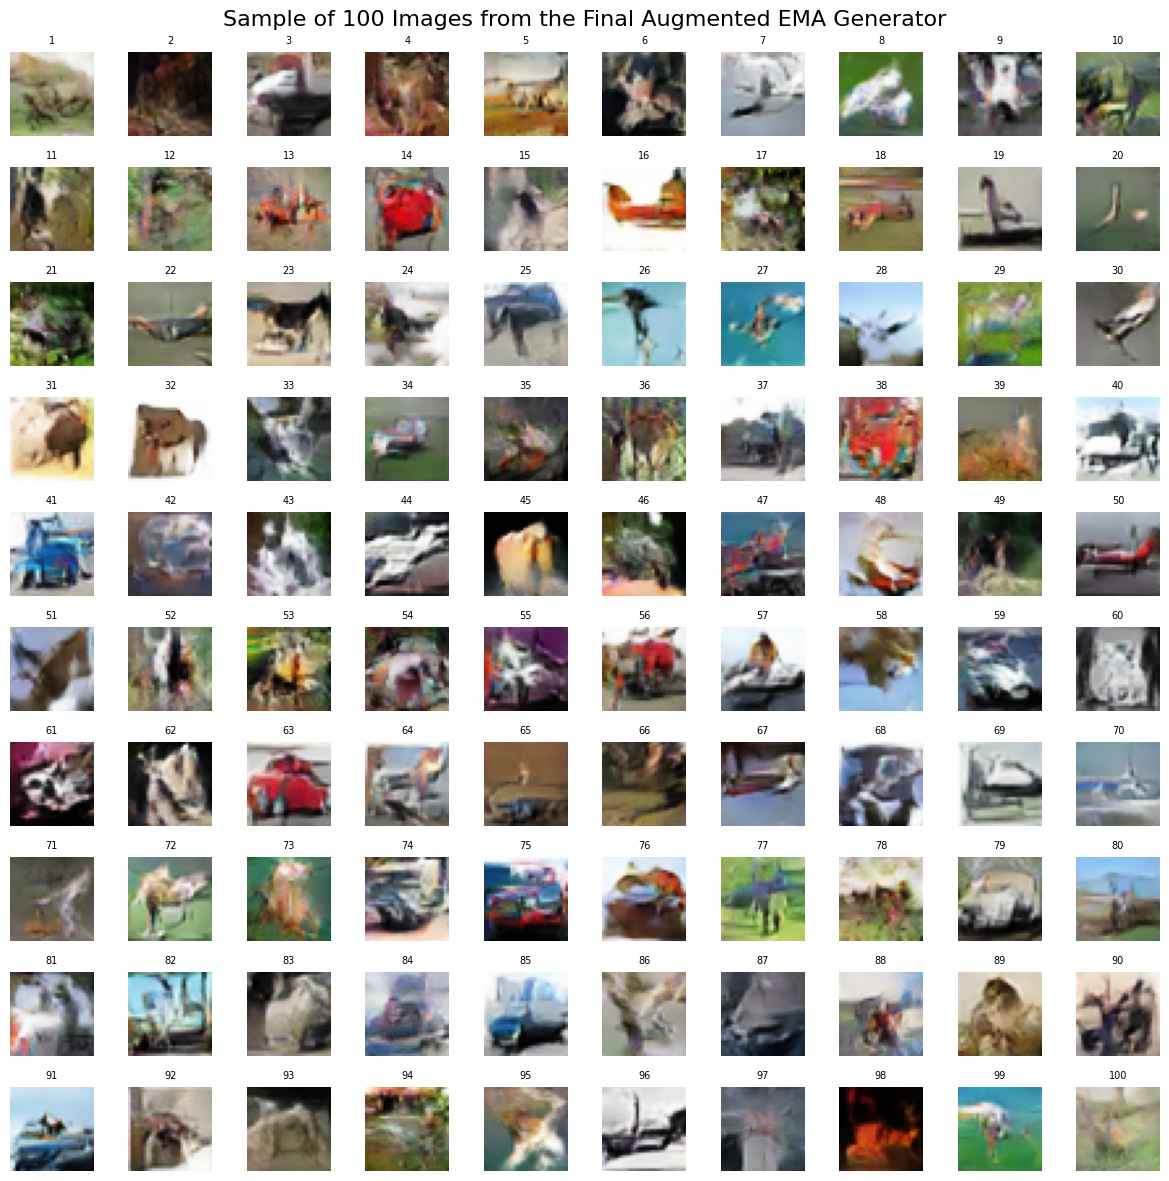

In [24]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(
    10,
    10,
    figsize=(12, 12)
)

for image_index, axis in enumerate(axes.flat):
    axis.imshow(generated_images_uint8[image_index])
    axis.set_title(
        str(image_index + 1),
        fontsize=7
    )
    axis.axis("off")

plt.suptitle(
    "Sample of 100 Images from the Final Augmented EMA Generator",
    fontsize=16
)

plt.tight_layout()
plt.show()

## References

Goodfellow, I., Pouget-Abadie, J., Mirza, M., Xu, B., Warde-Farley, D.,
Ozair, S., Courville, A., & Bengio, Y. (2014).
[Generative adversarial nets](https://arxiv.org/abs/1406.2661).
*Advances in Neural Information Processing Systems, 27*.

He, K., Zhang, X., Ren, S., & Sun, J. (2016).
[Deep residual learning for image recognition](https://openaccess.thecvf.com/content_cvpr_2016/html/He_Deep_Residual_Learning_CVPR_2016_paper.html).
*Proceedings of the IEEE Conference on Computer Vision and Pattern Recognition*,
770–778.

Heusel, M., Ramsauer, H., Unterthiner, T., Nessler, B., & Hochreiter, S.
(2017). [GANs trained by a two time-scale update rule converge to a local Nash equilibrium](https://proceedings.neurips.cc/paper/2017/hash/8a1d694707eb0fefe65871369074926d-Abstract.html).
*Advances in Neural Information Processing Systems, 30*.

Kingma, D. P., & Ba, J. (2015).
[Adam: A method for stochastic optimization](https://arxiv.org/abs/1412.6980).
*International Conference on Learning Representations*.

Kingma, D. P., & Welling, M. (2014).
[Auto-encoding variational Bayes](https://arxiv.org/abs/1312.6114).
*International Conference on Learning Representations*.

Krizhevsky, A., & Hinton, G. (2009).
[Learning multiple layers of features from tiny images](https://www.cs.toronto.edu/~kriz/learning-features-2009-TR.pdf).
University of Toronto.

Radford, A., Metz, L., & Chintala, S. (2016).
[Unsupervised representation learning with deep convolutional generative adversarial networks](https://arxiv.org/abs/1511.06434).
*International Conference on Learning Representations*.

Salimans, T., Goodfellow, I., Zaremba, W., Cheung, V., Radford, A., &
Chen, X. (2016).
[Improved techniques for training GANs](https://proceedings.neurips.cc/paper/2016/hash/8a3363abe792db2d8761d6403605aeb7-Abstract.html).
*Advances in Neural Information Processing Systems, 29*.

Sohn, K., Lee, H., & Yan, X. (2015).
[Learning structured output representation using deep conditional generative models](https://proceedings.neurips.cc/paper/5775-learning-structured-output-representation-using-deep-conditional-generative-models).
*Advances in Neural Information Processing Systems, 28*.

Sønderby, C. K., Raiko, T., Maaløe, L., Sønderby, S. K., & Winther, O.
(2016). [Ladder variational autoencoders](https://arxiv.org/abs/1602.02282).
*Advances in Neural Information Processing Systems, 29*.

Szegedy, C., Vanhoucke, V., Ioffe, S., Shlens, J., & Wojna, Z. (2016).
[Rethinking the Inception architecture for computer vision](https://arxiv.org/abs/1512.00567).
*Proceedings of the IEEE Conference on Computer Vision and Pattern Recognition*,
2818–2826.

Wang, Z., Bovik, A. C., Sheikh, H. R., & Simoncelli, E. P. (2004).
[Image quality assessment: From error visibility to structural similarity](https://ece.uwaterloo.ca/~z70wang/publications/ssim.html).
*IEEE Transactions on Image Processing, 13*(4), 600–612.

Yazıcı, Y., Foo, C.-S., Winkler, S., Yap, K.-H., Piliouras, G., &
Chandrasekhar, V. (2019).
[The unusual effectiveness of averaging in GAN training](https://openreview.net/forum?id=SJgw_sRqFQ).
*International Conference on Learning Representations*.